In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
from simulation.core import SimulationParams, SimulationRunner
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob

In [2]:
params_with_snipers = SimulationParams(
    enable_logging=True,
    n_snipers=2
)
runner_with = SimulationRunner(params_with_snipers)
result_with = runner_with.run()
print(f'With snipers — total events: {result_with.total_events:,}')
print(f'  Sniper 1 trades: {result_with.sniper1_trades:,}   PnL: {result_with.sniper1_pnl:.4f}')
print(f'  Sniper 2 trades: {result_with.sniper2_trades:,}   PnL: {result_with.sniper2_pnl:.4f}')
print(f'  Investor trades: {result_with.investor_trades:,}')

Logging to 20260601_015330_366060
With snipers — total events: 469,301
  Sniper 1 trades: 6,129   PnL: 245.7800
  Sniper 2 trades: 6,129   PnL: 245.7800
  Investor trades: 28,648


In [3]:
params_no_snipers = SimulationParams(
    enable_logging=True,
    n_snipers=0
)
runner_without = SimulationRunner(params_no_snipers)
result_without = runner_without.run()
print(f'Without snipers — total events: {result_without.total_events:,}')
print(f'  Investor trades: {result_without.investor_trades:,}')

Logging to 20260601_015342_422838
Without snipers — total events: 257,067
  Investor trades: 28,546


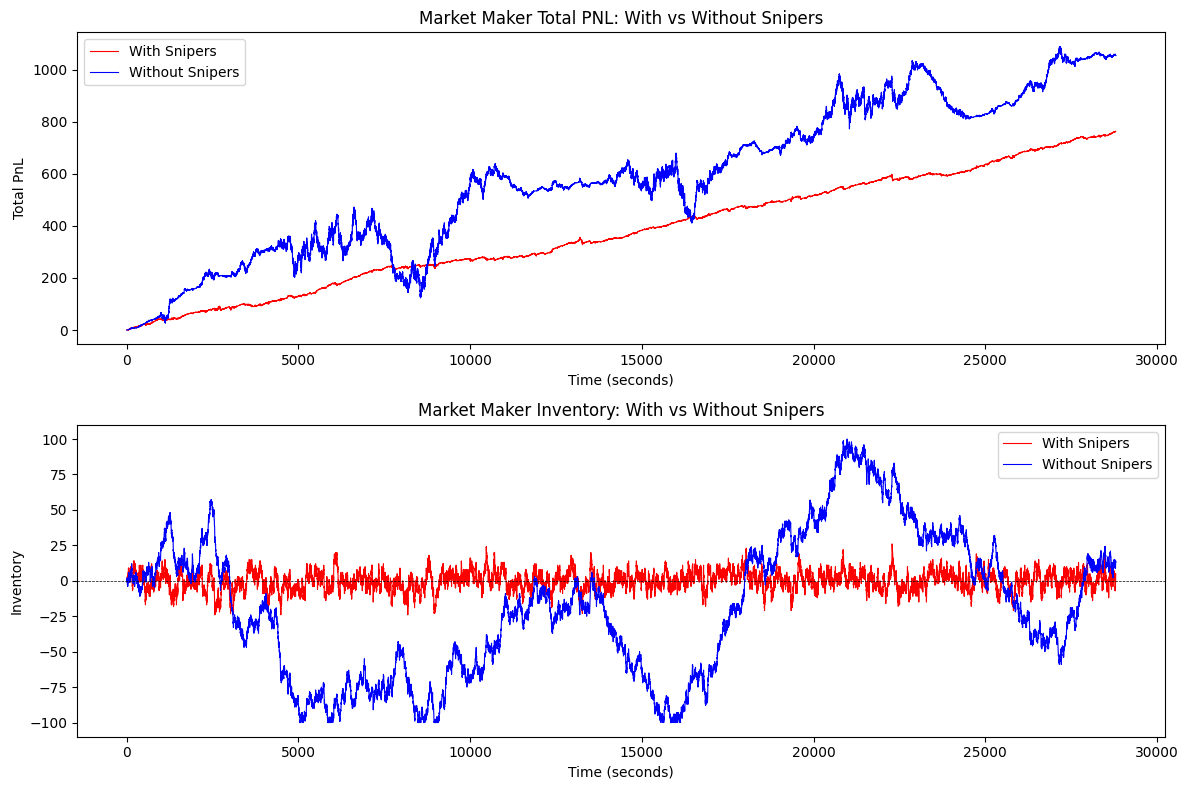

In [4]:
def pnl_series(history, key):
    times  = [h['time'] for h in history]
    values = [h[key]    for h in history]
    return times, values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Panel (a) — total PnL
t_w, pnl_w = pnl_series(result_with.mm_pnl_history,    'total_pnl')
t_n, pnl_n = pnl_series(result_without.mm_pnl_history, 'total_pnl')
ax1.plot(t_w, pnl_w, color='red',  linewidth=0.8, label='With Snipers')
ax1.plot(t_n, pnl_n, color='blue', linewidth=0.8, label='Without Snipers')
ax1.set_title('Market Maker Total PNL: With vs Without Snipers')
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Total PnL')
ax1.legend()
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useOffset=False))

# Panel (b) — inventory
t_w, inv_w = pnl_series(result_with.mm_pnl_history,    'inventory')
t_n, inv_n = pnl_series(result_without.mm_pnl_history, 'inventory')
ax2.plot(t_w, inv_w, color='red',  linewidth=0.8, label='With Snipers')
ax2.plot(t_n, inv_n, color='blue', linewidth=0.8, label='Without Snipers')
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_title('Market Maker Inventory: With vs Without Snipers')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Inventory')
ax2.legend()

plt.tight_layout()
plt.show()

In [5]:
def last(history, key):
    return history[-1][key] if history else float('nan')

rows = [
    ('MM Realized PNL',    f"{last(result_with.mm_pnl_history,'realized_pnl'):>14.4f}",
                           f"{last(result_without.mm_pnl_history,'realized_pnl'):>15.4f}"),
    ('MM Unrealized PNL',  f"{last(result_with.mm_pnl_history,'unrealized_pnl'):>14.4f}",
                           f"{last(result_without.mm_pnl_history,'unrealized_pnl'):>15.4f}"),
    ('MM Total PNL',       f"{last(result_with.mm_pnl_history,'total_pnl'):>14.4f}",
                           f"{last(result_without.mm_pnl_history,'total_pnl'):>15.4f}"),
    ('Avg Spread',         f"{result_with.avg_spread:>14.4f}",
                           f"{result_without.avg_spread:>15.4f}"),
    ('Sniper 1 PNL',       f"{result_with.sniper1_pnl:>14.4f}",    '              —'),
    ('Sniper 2 PNL',       f"{result_with.sniper2_pnl:>14.4f}",    '              —'),
    ('Sniper Fills',       f"{result_with.sniper1_trades + result_with.sniper2_trades:>14,}",
                           '              —'),
    ('Investor Fills',     f"{result_with.investor_trades:>14,}",
                           f"{result_without.investor_trades:>15,}"),
]

header = f"{'':28}  {'With Snipers':>14}  {'Without Snipers':>15}"
print(header)
print('-' * len(header))
for label, with_val, no_val in rows:
    print(f"{label:28}  {with_val}  {no_val}")

                                With Snipers  Without Snipers
-------------------------------------------------------------
MM Realized PNL                     763.6467        1057.2190
MM Unrealized PNL                    -0.2167          -2.3390
MM Total PNL                        763.4300        1054.8800
Avg Spread                            0.0929           0.0842
Sniper 1 PNL                        245.7800                —
Sniper 2 PNL                        245.7800                —
Sniper Fills                          12,258                —
Investor Fills                        28,648           28,546


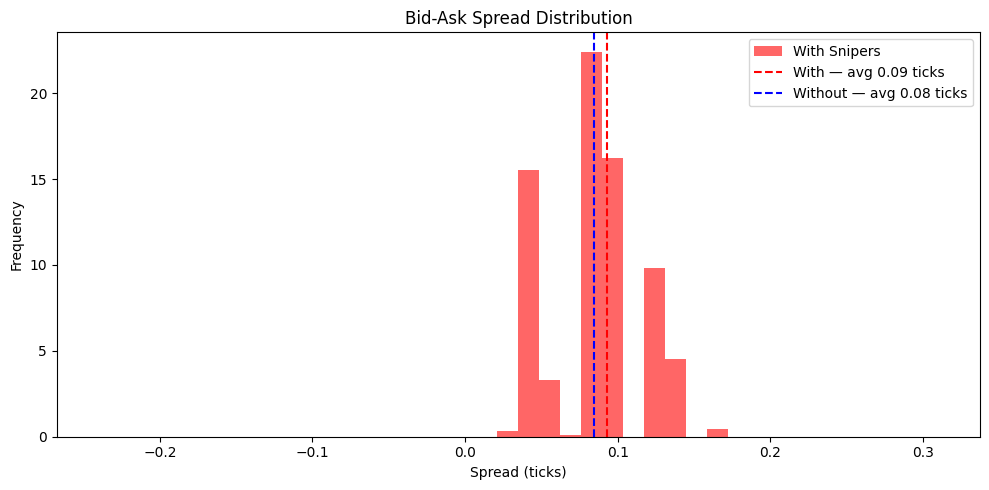

In [6]:


fig, ax = plt.subplots(figsize=(10, 5))

ts = params_with_snipers.tick_size

# Load spread from log CSV if available
log_files = sorted(glob.glob(os.path.join(params_with_snipers.log_dir, 'events_*.csv')))
if log_files:
    df = pd.read_csv(log_files[-1])
    spreads_with = df[df['book_bid'].notna() & df['book_ask'].notna()].eval('book_ask - book_bid')
    spreads_with_ticks = spreads_with
    ax.hist(spreads_with_ticks.dropna(), bins=40, alpha=0.6, color='red',
            label='With Snipers', density=True)

# Without snipers: derive from pnl_history spread samples
spread_w_ticks = result_with.avg_spread
spread_n_ticks = result_without.avg_spread
ax.axvline(spread_w_ticks,  color='red',  linestyle='--', linewidth=1.5,
           label=f'With — avg {spread_w_ticks:.2f} ticks')
ax.axvline(spread_n_ticks, color='blue', linestyle='--', linewidth=1.5,
           label=f'Without — avg {spread_n_ticks:.2f} ticks')

ax.set_title('Bid-Ask Spread Distribution')
ax.set_xlabel('Spread (ticks)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()